<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/imdb_sentiment_analysis/blob/main/Sentiment_Analysis_IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Imports

In [ ]:
import os
import re
import glob
import random
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from helper import plot_training_curve, evaluate_model

# 2. Reproducibility

In [ ]:

SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)


#3.  Data Preparation and Utilities

##3.1. Text Cleaning Utility

In [ ]:
url_pattern     = re.compile(r'https?://\S+|www\.\S+')
numbers_pattern = re.compile(r'\d+')

def remove_unwanted(text):
    """
    Clean a raw IMDB review string for use with a Keras TextVectorization layer.

    Handles artifacts that TextVectorization's 'lower_and_strip_punctuation'
    standardizer cannot remove. Lowercasing and punctuation removal are
    intentionally left to the vectorizer.

    Cleaning steps: strip HTML tags, remove URLs, remove digits,
    normalize whitespace.

    Parameters
    ----------
    text : str
        A single raw review string.

    Returns
    -------
    str
        Cleaned review string.
    """

    text = BeautifulSoup(text, "html.parser").get_text()
    text = url_pattern.sub('', text)
    text = numbers_pattern.sub('', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

##3.2. Data Loading and Cleaning

In [ ]:
def load_and_clean_data():
    """
    Download the IMDB dataset from Kaggle, map sentiment labels to integers,
    and apply text cleaning to all reviews.

    Returns
    -------
    pd.DataFrame
        DataFrame with two columns:
          - 'review'    : cleaned review text (str)
          - 'sentiment' : binary label — 1 (positive) or 0 (negative)
    """
    path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
    csv_file_path = os.path.join(path, 'IMDB Dataset.csv')

    df = pd.read_csv(csv_file_path)
    df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
    df['review'] = df['review'].apply(remove_unwanted)
    return df

##3.3. Dataset Splitting

In [ ]:
def prepare_datasets(df, text_col='review', label_col='sentiment', batch_size=64):
    """
    Split a DataFrame into train/val/test tf.data.Datasets.

    Split ratio: 80% train, 10% validation, 10% test — stratified on label.
    The training dataset is shuffled; val and test are not.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the text and label columns.
    text_col : str, optional
        Name of the review text column. Default: 'review'.
    label_col : str, optional
        Name of the binary sentiment label column. Default: 'sentiment'.
    batch_size : int, optional
        Batch size for all three datasets. Default: 64.

    Returns
    -------
    train_ds : tf.data.Dataset
    val_ds   : tf.data.Dataset
    test_ds  : tf.data.Dataset
    X_train  : pd.Series
        Raw training texts, needed to adapt the TextVectorization layer.
    """
    X = df[text_col]
    y = df[label_col]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
    )

    # Reshape labels to (N, 1) for compatibility with model output
    y_train = y_train.values.reshape(-1, 1)
    y_val = y_val.values.reshape(-1, 1)
    y_test = y_test.values.reshape(-1, 1)

    AUTOTUNE = tf.data.AUTOTUNE

    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_train, y_train))
        .shuffle(buffer_size=10000, seed=SEED)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )
    val_ds  = tf.data.Dataset.from_tensor_slices((X_val,  y_val )).batch(batch_size).prefetch(AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, X_train

##3.4. Model Building Utility (Base Models)

In [ ]:
def build_model(
    X_train_texts,
    model_type="bilstm",
    vocab_size=20000,
    max_len=300,
    embedding_dim=128,
    units=128
):
    """
    Build and compile a Keras sentiment classification model.

    All architectures share the same input pipeline (TextVectorization → Embedding)
    and classification head (Dense(64) → Dropout → Dense(1, sigmoid)).
    Each model type has an individually tuned learning rate.

    Parameters
    ----------
    X_train_texts : pd.Series or list of str
        Raw training texts used to adapt the TextVectorization layer.
    model_type : str, optional
        Architecture to use. One of:
          - 'dense'  : GlobalAveragePooling over embeddings. Fast baseline.
          - 'cnn'    : Two Conv1D layers with BatchNorm and L2 regularization.
          - 'lstm'   : Single unidirectional LSTM.
          - 'bilstm' : Stacked Bidirectional LSTM for deeper sequence understanding.
        Default: 'bilstm'.
    vocab_size : int, optional
        Maximum vocabulary size for the vectorizer. Default: 20000.
    max_len : int, optional
        Sequence length after vectorization (truncate/pad). Default: 300.
    embedding_dim : int, optional
        Dimensionality of the embedding vectors. Default: 128.
    units : int, optional
        Base number of units for CNN filters or LSTM units. Default: 128.

    Returns
    -------
    tf.keras.Sequential
        Compiled Keras model ready for training.

    Raises
    ------
    ValueError
        If model_type is not one of: dense, cnn, lstm, bilstm.
    """
    vectorizer = tf.keras.layers.TextVectorization(
        max_tokens=vocab_size,
        output_mode='int',
        output_sequence_length=max_len,
        standardize='lower_and_strip_punctuation'
    )
    vectorizer.adapt(X_train_texts)

    vocab_actual = len(vectorizer.get_vocabulary())
    supports_masking = model_type in ("lstm", "bilstm")

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(1,), dtype=tf.string),
        vectorizer,
        tf.keras.layers.Embedding(
            input_dim=vocab_actual,
            output_dim=embedding_dim,
            mask_zero=supports_masking
        )
    ])

    if model_type == "dense":
        model.add(tf.keras.layers.GlobalAveragePooling1D())

    elif model_type == "cnn":
        model.add(tf.keras.layers.SpatialDropout1D(0.3))
        model.add(tf.keras.layers.Conv1D(units, 5, activation='relu', padding='same',
                                         kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(0.4))
        model.add(tf.keras.layers.Conv1D(units // 2, 3, activation='relu',
                                         kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
        model.add(tf.keras.layers.Dropout(0.4))
        model.add(tf.keras.layers.GlobalMaxPooling1D())

    elif model_type == "lstm":
        model.add(tf.keras.layers.SpatialDropout1D(0.3))
        model.add(tf.keras.layers.LSTM(units, dropout=0.3, recurrent_dropout=0))

    elif model_type == "bilstm":
        model.add(tf.keras.layers.SpatialDropout1D(0.3))
        model.add(tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(units, dropout=0.3, recurrent_dropout=0, return_sequences=True)
        ))
        model.add(tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(units // 2, dropout=0.3, recurrent_dropout=0)
        ))

    else:
        raise ValueError(f"Invalid model_type: '{model_type}'. Choose from: dense, cnn, lstm, bilstm")

    model.add(tf.keras.layers.Dense(64, activation='relu',
                                    kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
    model.add(tf.keras.layers.Dropout(0.4))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    lr_map = {
        "dense"  : 1e-4,
        "cnn"    : 1e-4,
        "lstm"   : 1e-4,
        "bilstm" : 1e-4,
    }

    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_map[model_type]),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )
    return model

##3.5. Model Training Utility

In [ ]:
def train_model(model, train_ds, val_ds, experiment_name="base_model", epochs=40):
    """
    Train a Keras model with early stopping, learning rate scheduling, and CSV logging.

    Parameters
    ----------
    model : tf.keras.Model
        A compiled Keras model.
    train_ds : tf.data.Dataset
        Batched and shuffled training dataset.
    val_ds : tf.data.Dataset
        Batched validation dataset.
    experiment_name : str, optional
        Used to name the CSV log file. Default: 'base_model'.
    epochs : int, optional
        Maximum number of training epochs. Default: 40.

    Returns
    -------
    history : tf.keras.callbacks.History
    model   : tf.keras.Model
        Model restored to best weights by EarlyStopping.
    csv_log_path : str
        Path to the CSV training log, for use with plot_training_curve().
    """
    csv_log_path = f"{experiment_name}_training_log.csv"

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=4,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.TerminateOnNaN(),
        tf.keras.callbacks.CSVLogger(
            filename=csv_log_path,
            append=False
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks
    )
    return history, model, csv_log_path

#4. Training and Evaluation (Base Models)

In [ ]:
df = load_and_clean_data()

train_ds, val_ds, test_ds, X_train = prepare_datasets(df, batch_size=64)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


##4.1. Dense Model

In [ ]:
dnn_model = build_model(X_train_texts=X_train, model_type="dense")
dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,568,321 (9.80 MB)

 Trainable params: 2,568,321 (9.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dnn_history, dnn_model, dnn_csv_path = train_model(
    dnn_model, train_ds, val_ds, experiment_name="dnn", epochs=40
)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.5481 - loss: 0.6975 - val_accuracy: 0.6888 - val_loss: 0.6659 - learning_rate: 1.0000e-04
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7209 - loss: 0.6383 - val_accuracy: 0.8154 - val_loss: 0.5356 - learning_rate: 1.0000e-04
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8052 - loss: 0.5061 - val_accuracy: 0.8426 - val_loss: 0.4370 - learning_rate: 1.0000e-04
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8449 - loss: 0.4129 - val_accuracy: 0.8616 - val_loss: 0.3806 - learning_rate: 1.0000e-04
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8631 - loss: 0.3660 - val_accuracy: 0.8476 - val_loss: 0.3791 - learning_rate: 1.0000e-04
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8748 - loss: 0.3397 - val_accuracy: 0.8756 - val_loss: 0.3418 - learning_rate: 1.0000e-04
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accu

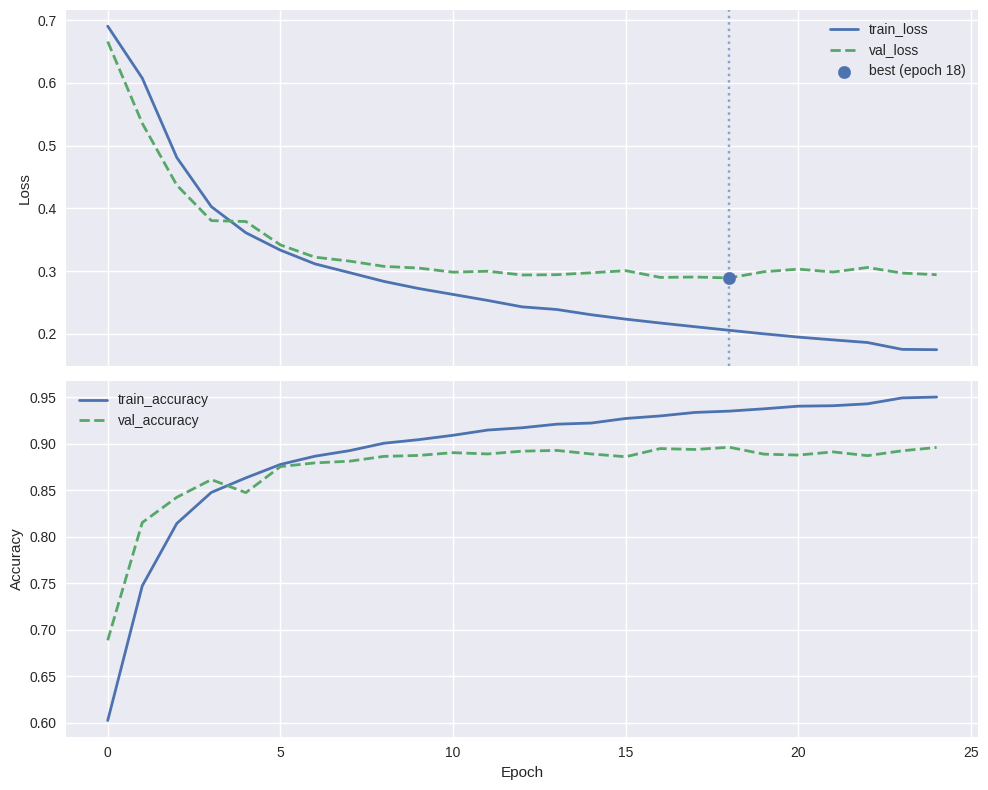

In [ ]:
plot_training_curve(dnn_csv_path)

Test Loss:     0.2753
Test Accuracy: 0.8980

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      2500
    Positive       0.89      0.91      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



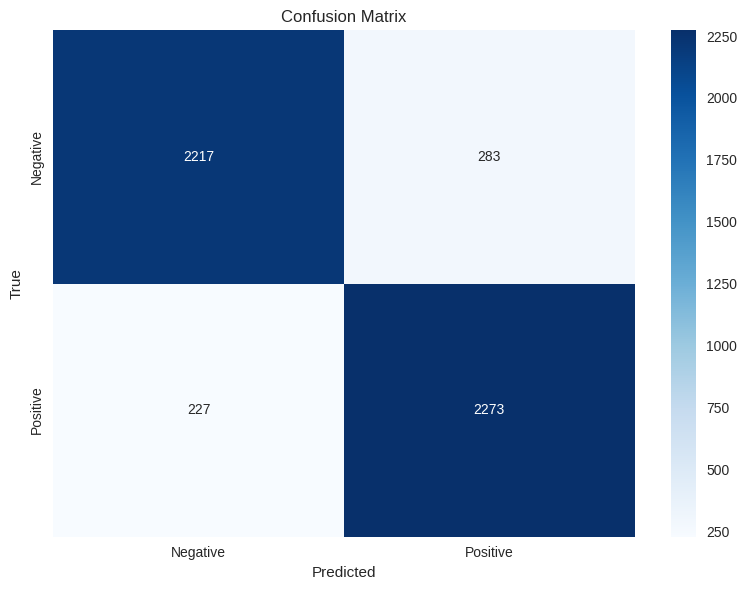

In [ ]:
evaluate_model(dnn_model, test_ds, class_names=["Negative", "Positive"])

In [ ]:
dnn_model.save("dnn_model_v1.keras")

##4.2. CNN Model

In [ ]:
cnn_model = build_model(X_train_texts=X_train, model_type="cnn")
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 300, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 300, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 298, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 298, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,671,425 (10.19 MB)

 Trainable params: 2,671,169 (10.19 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
cnn_history, cnn_model, cnn_csv_path = train_model(
    cnn_model, train_ds, val_ds, experiment_name="cnn", epochs=40
)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.5050 - loss: 1.0589 - val_accuracy: 0.5280 - val_loss: 0.7189 - learning_rate: 1.0000e-04
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5158 - loss: 0.7218 - val_accuracy: 0.5706 - val_loss: 0.7148 - learning_rate: 1.0000e-04
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.5547 - loss: 0.7083 - val_accuracy: 0.7056 - val_loss: 0.6546 - learning_rate: 1.0000e-04
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6806 - loss: 0.6237 - val_accuracy: 0.7940 - val_loss: 0.5268 - learning_rate: 1.0000e-04
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7895 - loss: 0.4826 - val_accuracy: 0.8408 - val_loss: 0.4419 - learning_rate: 1.0000e-04
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8333 - loss: 0.4068 - val_accuracy: 0.8586 - val_loss: 0.4018 - learning_rate: 1.0000e-04
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/ste

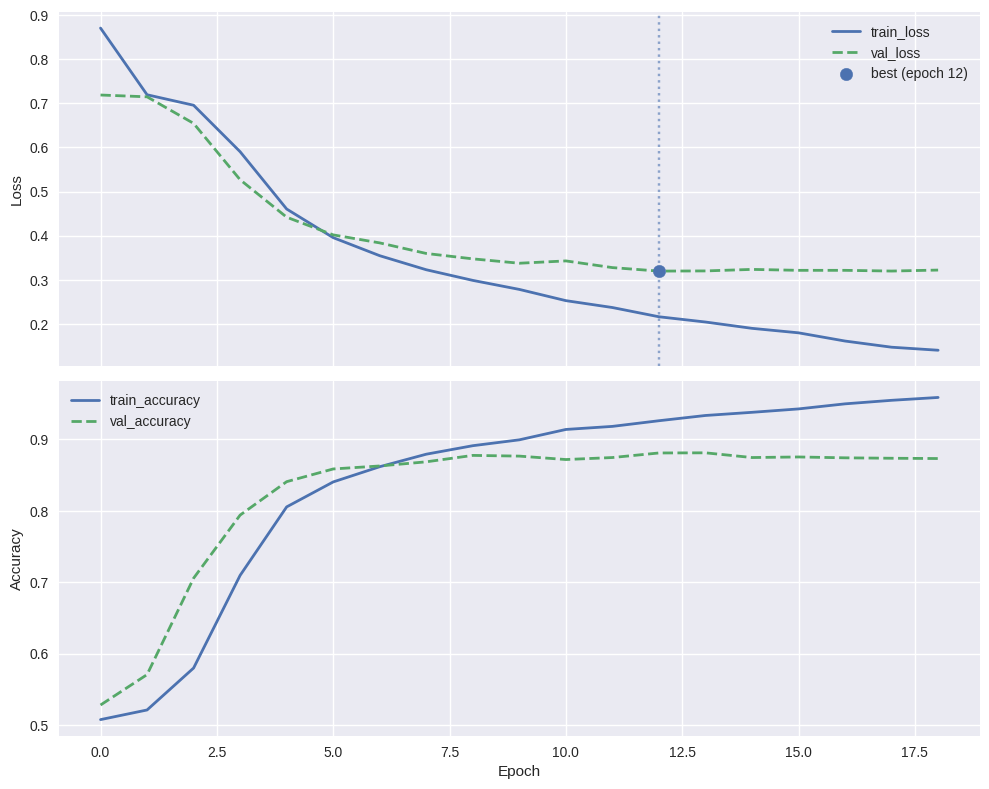

In [ ]:
plot_training_curve(cnn_csv_path)

Test Loss:     0.3155
Test Accuracy: 0.8836

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.88      2500
    Positive       0.89      0.88      0.88      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



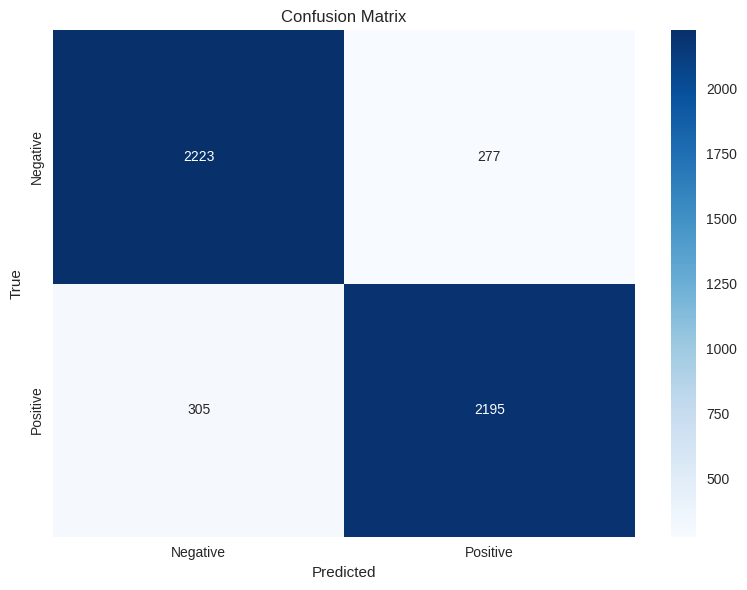

In [ ]:
evaluate_model(cnn_model, test_ds, class_names=["Negative", "Positive"])

In [ ]:
cnn_model.save("cnn_model_v1.keras")

##4.3. LSTM Model

In [ ]:
lstm_model = build_model(X_train_texts=X_train, model_type="lstm")
lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 300, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history, lstm_model, lstm_csv_path = train_model(
    lstm_model, train_ds, val_ds, experiment_name="lstm", epochs=40
)


Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5675 - loss: 0.6661 - val_accuracy: 0.8684 - val_loss: 0.3447 - learning_rate: 1.0000e-04
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8648 - loss: 0.3361 - val_accuracy: 0.8914 - val_loss: 0.2804 - learning_rate: 1.0000e-04
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8970 - loss: 0.2671 - val_accuracy: 0.8900 - val_loss: 0.2839 - learning_rate: 1.0000e-04
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9121 - loss: 0.2350 - val_accuracy: 0.8932 - val_loss: 0.2726 - learning_rate: 1.0000e-04
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9267 - loss: 0.2031 - val_accuracy: 0.8954 - val_loss: 0.2833 - learning_rate: 1.0000e-04
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.9350 - loss: 0.1834 - val_accuracy: 0.8900 - val_loss: 0.2935 - learning_rate: 1.0000e-04
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/ste

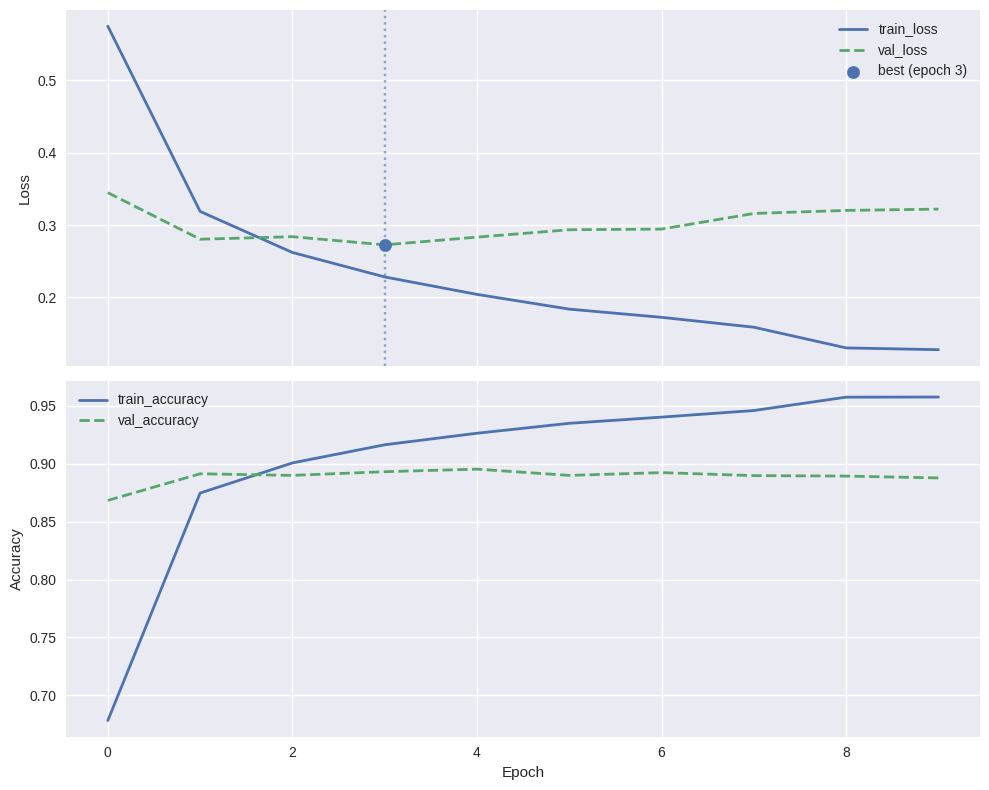

In [ ]:
plot_training_curve(lstm_csv_path)

Test Loss:     0.2661
Test Accuracy: 0.8942

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89      2500
    Positive       0.89      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



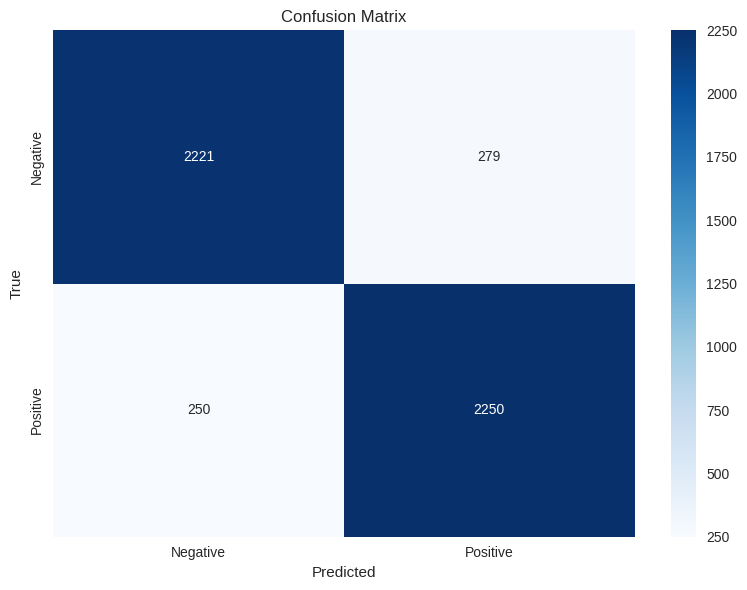

In [ ]:
evaluate_model(lstm_model, test_ds, class_names=["Negative", "Positive"])

In [ ]:
lstm_model.save("lstm_model_v1.keras")

##4.4. BiLSTM Model

In [ ]:
bilstm_model = build_model(X_train_texts=X_train, model_type="bilstm")
bilstm_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_3            │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 300, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,995,841 (11.43 MB)

 Trainable params: 2,995,841 (11.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
bilstm_history, bilstm_model, bilstm_csv_path = train_model(
    bilstm_model, train_ds, val_ds, experiment_name="bilstm", epochs=40
)


Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.6013 - loss: 0.6325 - val_accuracy: 0.8782 - val_loss: 0.3046 - learning_rate: 1.0000e-04
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8796 - loss: 0.3014 - val_accuracy: 0.8912 - val_loss: 0.2709 - learning_rate: 1.0000e-04
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9071 - loss: 0.2446 - val_accuracy: 0.8924 - val_loss: 0.2656 - learning_rate: 1.0000e-04
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9232 - loss: 0.2103 - val_accuracy: 0.8926 - val_loss: 0.2723 - learning_rate: 1.0000e-04
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9347 - loss: 0.1836 - val_accuracy: 0.8928 - val_loss: 0.2886 - learning_rate: 1.0000e-04
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9423 - loss: 0.1671 - val_accuracy: 0.8838 - val_loss: 0.3110 - learning_rate: 1.0000e-04
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

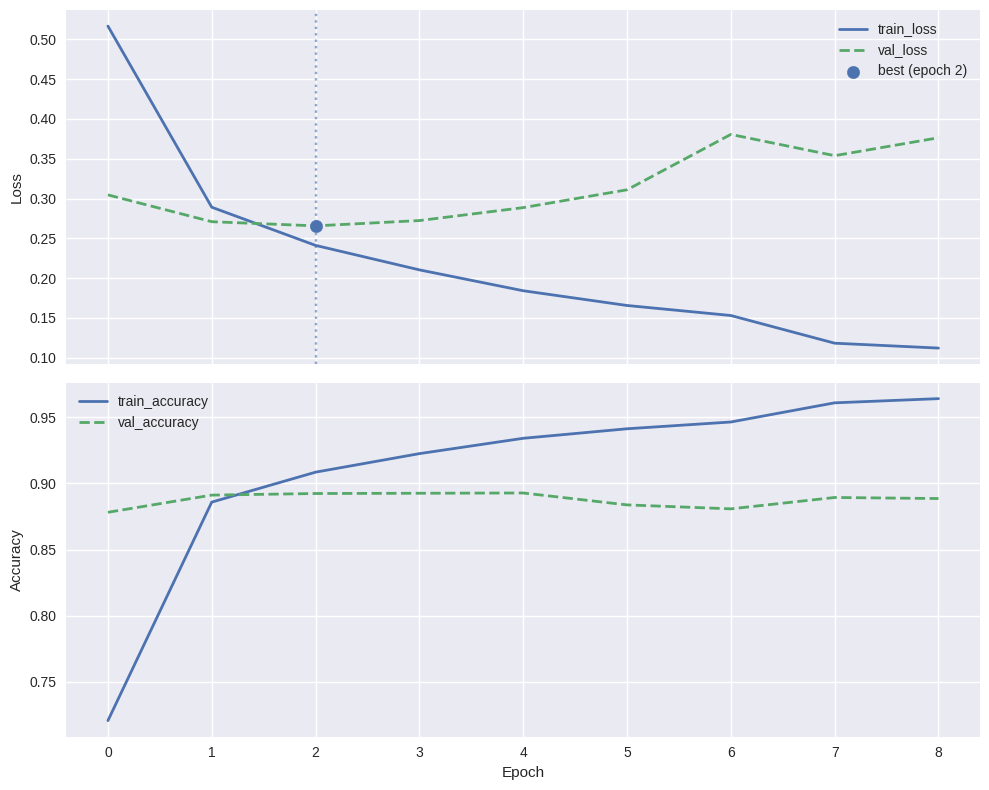

In [ ]:
plot_training_curve(bilstm_csv_path)

Test Loss:     0.2546
Test Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90      2500
    Positive       0.90      0.90      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



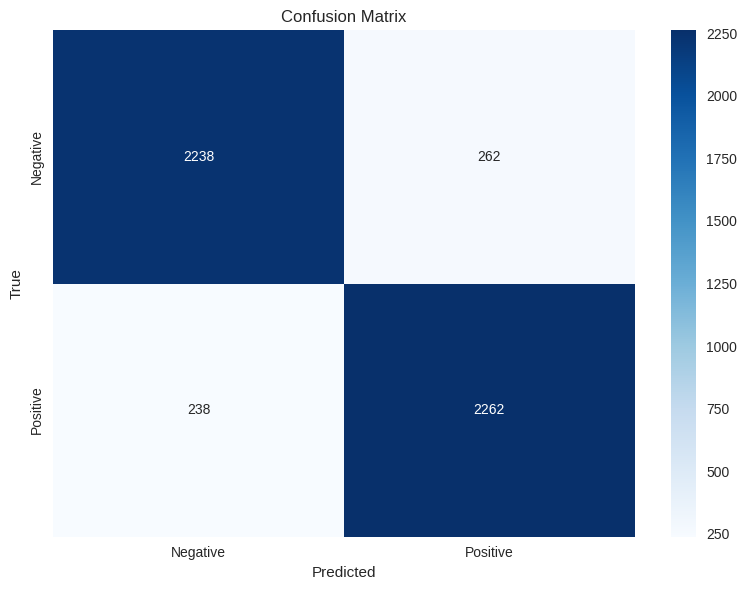

In [ ]:
evaluate_model(bilstm_model, test_ds, class_names=["Negative", "Positive"])

In [ ]:
bilstm_model.save("bilstm_model_v1.keras")

#5. Enhanced Model Utilities (GloVe & Attention)

##5.1. GloVe Embeddings Utilities

In [ ]:
def load_glove_embeddings(glove_path, embedding_dim=100):
    """
    Load GloVe vectors from a .txt file into a dictionary.

    Parameters
    ----------
    glove_path : str
        Full path to the GloVe .txt file (e.g. 'glove.6B.100d.txt').
    embedding_dim : int, optional
        Must match the file downloaded (100 or 200). Default: 100.

    Returns
    -------
    dict
        Mapping of {word: np.ndarray of shape (embedding_dim,)}.
    """
    embeddings_index = {}
    with open(glove_path, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word   = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings_index[word] = vector
    print(f"Loaded {len(embeddings_index):,} GloVe vectors (dim={embedding_dim})")
    return embeddings_index


def build_embedding_matrix(vocabulary, embeddings_index, embedding_dim=100):
    """
    Map a TextVectorization vocabulary to GloVe vectors.

    Words not found in GloVe get a small random vector rather than zeros,
    since zero vectors are indistinguishable from padding and hurt training.

    Parameters
    ----------
    vocabulary : list of str
        List returned by vectorizer.get_vocabulary().
    embeddings_index : dict
        Output of load_glove_embeddings().
    embedding_dim : int, optional
        Must match embeddings_index. Default: 100.

    Returns
    -------
    np.ndarray
        Embedding matrix of shape (vocab_size, embedding_dim).
    """
    vocab_size = len(vocabulary)
    embedding_matrix = np.random.normal(scale=0.01, size=(vocab_size, embedding_dim)).astype("float32")

    hits, misses = 0, 0
    for idx, word in enumerate(vocabulary):
        vector = embeddings_index.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector
            hits += 1
        else:
            misses += 1

    print(f"Embedding matrix: {hits:,} hits, {misses:,} misses out of {vocab_size:,} vocab tokens")
    return embedding_matrix



##5.2. Attention Pooling and Multi-kernel CNN Layer

In [ ]:
class _AttentionPooling(tf.keras.layers.Layer):
    """
    Soft attention pooling over the time dimension.

    Learns a scalar importance score per timestep, then returns a weighted
    sum of all hidden states. More expressive than taking only the last
    hidden state, especially for long IMDB reviews.
    """
    supports_masking = True

    def build(self, input_shape):
        self.W = self.add_weight(
            name        = "attn_weight",
            shape       = (input_shape[-1], 1),
            initializer = "glorot_uniform",
            trainable   = True,
        )
        super().build(input_shape)

    def call(self, x, mask=None):
        scores = tf.squeeze(tf.matmul(x, self.W), axis=-1)
        if mask is not None:
            mask = tf.cast(mask, tf.float32)
            scores += (1.0 - mask) * -1e9
        weights = tf.nn.softmax(scores, axis=-1)
        weights = tf.expand_dims(weights, -1)
        return tf.reduce_sum(x * weights, axis=1)

    def compute_mask(self, inputs, mask=None):
        return None

    def get_config(self):
        return super().get_config()


def _build_cnn_functional(vectorizer, vocab_actual, embedding_dim, embedding_init, units):
    """
    Build a parallel multi-kernel CNN using the Functional API.

    Uses three parallel Conv1D branches with kernel sizes 3, 4, 5 to capture
    trigram, 4-gram, and 5-gram patterns simultaneously, then concatenates
    their pooled outputs before the classification head.

    Parameters
    ----------
    vectorizer : tf.keras.layers.TextVectorization
        Already-adapted vectorization layer.
    vocab_actual : int
        Real vocabulary size after adaptation.
    embedding_dim : int
        Dimensionality of embedding vectors.
    embedding_init : str or tf.keras.initializers.Initializer
        Embedding initializer — either 'uniform' or a GloVe Constant initializer.
    units : int
        Number of filters per Conv1D branch.

    Returns
    -------
    tf.keras.Model
        Compiled Keras model.
    """
    text_input = tf.keras.Input(shape=(1,), dtype=tf.string, name="text_input")
    x = vectorizer(text_input)
    x = tf.keras.layers.Embedding(
        input_dim              = vocab_actual,
        output_dim             = embedding_dim,
        embeddings_initializer = embedding_init,
        mask_zero              = False,
        trainable              = True,
        name                   = "embedding",
    )(x)
    x = tf.keras.layers.SpatialDropout1D(0.3)(x)

    branches = []
    for kernel_size in [3, 4, 5]:
        branch = tf.keras.layers.Conv1D(
            units, kernel_size, activation="relu", padding="same",
            name=f"conv_{kernel_size}"
        )(x)
        branch = tf.keras.layers.BatchNormalization(name=f"bn_{kernel_size}")(branch)
        branch = tf.keras.layers.GlobalMaxPooling1D(name=f"pool_{kernel_size}")(branch)
        branch = tf.keras.layers.Dropout(0.3)(branch)
        branches.append(branch)

    merged = tf.keras.layers.concatenate(branches, name="merge")

    out = tf.keras.layers.Dense(128, activation="relu",
                                kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                                name="dense_1")(merged)
    out = tf.keras.layers.Dropout(0.4, name="dropout")(out)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(out)

    model = tf.keras.Model(inputs=text_input, outputs=out, name="multi_kernel_cnn")
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss      = "binary_crossentropy",
        metrics   = ["accuracy"],
    )
    return model



##5.3. Enhanced Model Building Utility

In [ ]:
def build_model_v2(
    X_train_texts,
    model_type       = "bilstm",
    vocab_size       = 20000,
    max_len          = 300,
    embedding_dim    = 100,
    units            = 128,
    glove_path       = None,
    embeddings_index = None,
):
    """
    Build and compile a GloVe-enhanced Keras sentiment classification model.

    Upgraded version of build_model with pretrained GloVe embeddings,
    a multi-kernel CNN, and attention pooling for BiLSTM.
    All architectures share the same input pipeline (TextVectorization → Embedding)
    and are fine-tuned on top of GloVe vectors.

    Parameters
    ----------
    X_train_texts : pd.Series or list of str
        Raw training texts used to adapt the TextVectorization layer.
    model_type : str, optional
        Architecture to use. One of:
          - 'dense'  : GlobalAveragePooling over embeddings. Fast baseline.
          - 'cnn'    : Parallel Conv1D branches with kernel sizes 3, 4, 5.
          - 'lstm'   : Single unidirectional LSTM.
          - 'bilstm' : Stacked Bidirectional LSTM with attention pooling.
        Default: 'bilstm'.
    vocab_size : int, optional
        Maximum vocabulary size for the vectorizer. Default: 20000.
    max_len : int, optional
        Sequence length after vectorization (truncate/pad). Default: 300.
    embedding_dim : int, optional
        Dimensionality of embedding vectors. Must match GloVe file. Default: 100.
    units : int, optional
        Base number of units for CNN filters or LSTM units. Default: 128.
    glove_path : str, optional
        Path to GloVe .txt file. Used only if embeddings_index is not provided.
    embeddings_index : dict, optional
        Pre-loaded GloVe dict from load_glove_embeddings(). Preferred over
        glove_path to avoid reloading on every call.

    Returns
    -------
    tf.keras.Model
        Compiled Keras model ready for training.

    Raises
    ------
    ValueError
        If model_type is not one of: dense, cnn, lstm, bilstm.

    Example
    -------
    >>> embeddings_index = load_glove_embeddings("/path/to/glove.6B.100d.txt")
    >>> model = build_model_v2(X_train, model_type="bilstm", embeddings_index=embeddings_index)
    """
    vectorizer = tf.keras.layers.TextVectorization(
        max_tokens             = vocab_size,
        output_mode            = "int",
        output_sequence_length = max_len,
        standardize            = "lower_and_strip_punctuation",
    )
    vectorizer.adapt(X_train_texts)
    vocabulary   = vectorizer.get_vocabulary()
    vocab_actual = len(vocabulary)

    if embeddings_index is not None:
        embedding_matrix = build_embedding_matrix(vocabulary, embeddings_index, embedding_dim)
        embedding_init   = tf.keras.initializers.Constant(embedding_matrix)
    elif glove_path is not None:
        _index           = load_glove_embeddings(glove_path, embedding_dim)
        embedding_matrix = build_embedding_matrix(vocabulary, _index, embedding_dim)
        embedding_init   = tf.keras.initializers.Constant(embedding_matrix)
    else:
        embedding_init   = "uniform"

    supports_masking = model_type in ("lstm", "bilstm")

    if model_type == "cnn":
        return _build_cnn_functional(
            vectorizer, vocab_actual, embedding_dim, embedding_init, units
        )

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(1,), dtype=tf.string),
        vectorizer,
        tf.keras.layers.Embedding(
            input_dim              = vocab_actual,
            output_dim             = embedding_dim,
            embeddings_initializer = embedding_init,
            mask_zero              = supports_masking,
            trainable              = True,
        ),
    ])

    if model_type == "dense":
        model.add(tf.keras.layers.GlobalAveragePooling1D())

    elif model_type == "lstm":
        model.add(tf.keras.layers.SpatialDropout1D(0.3))
        model.add(tf.keras.layers.LSTM(units, dropout=0.3))

    elif model_type == "bilstm":
        model.add(tf.keras.layers.SpatialDropout1D(0.3))
        model.add(tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(units, dropout=0.3, return_sequences=True)
        ))
        model.add(tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(units // 2, dropout=0.3, return_sequences=True)
        ))
        model.add(_AttentionPooling())

    else:
        raise ValueError(f"Invalid model_type: '{model_type}'. Choose from: dense, cnn, lstm, bilstm")

    model.add(tf.keras.layers.Dense(128, activation="relu",
                                    kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
    model.add(tf.keras.layers.Dropout(0.4))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss      = "binary_crossentropy",
        metrics   = ["accuracy"],
    )
    return model

##5.4. Load GloVe Embeddings

In [ ]:
GLOVE_DIR  = "/content/drive/MyDrive/glove"
GLOVE_ZIP  = os.path.join(GLOVE_DIR, "glove.6B.zip")
GLOVE_FILE = os.path.join(GLOVE_DIR, "glove.6B.100d.txt")
GLOVE_URL  = "https://nlp.stanford.edu/data/glove.6B.zip"

os.makedirs(GLOVE_DIR, exist_ok=True)

if not os.path.exists(GLOVE_ZIP) and not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe (~822MB)... this takes a few minutes.")
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
    print("Download complete.")
else:
    print("GloVe zip already on Drive, skipping download.")

if not os.path.exists(GLOVE_FILE):
    print("Extracting glove.6B.100d.txt ...")
    with zipfile.ZipFile(GLOVE_ZIP, "r") as z:
        z.extract("glove.6B.100d.txt", GLOVE_DIR)
    print("Extraction complete.")
else:
    print("glove.6B.100d.txt already extracted, skipping.")

embeddings_index = load_glove_embeddings(GLOVE_FILE, embedding_dim=100)

GloVe zip already on Drive, skipping download.
glove.6B.100d.txt already extracted, skipping.
Loaded 400,000 GloVe vectors (dim=100)


#6. Training and Evaluation (Enhanced Models)

##6.1. Dense Model (GloVe)

In [ ]:
dnn_model_v2 = build_model_v2(
    X_train_texts    = X_train,
    model_type       = "dense",
    embedding_dim    = 100,
    embeddings_index = embeddings_index
)
dnn_model_v2.summary()

Embedding matrix: 19,266 hits, 734 misses out of 20,000 vocab tokens


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_4            │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 300, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,013,057 (7.68 MB)

 Trainable params: 2,013,057 (7.68 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dnn_history_v2, dnn_model_v2, dnn_csv_path_v2 = train_model(
    dnn_model_v2, train_ds, val_ds,
    experiment_name="dnn_v2",
    epochs=40
)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5921 - loss: 0.6765 - val_accuracy: 0.7878 - val_loss: 0.5225 - learning_rate: 3.0000e-04
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7961 - loss: 0.4806 - val_accuracy: 0.8510 - val_loss: 0.3886 - learning_rate: 3.0000e-04
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8527 - loss: 0.3731 - val_accuracy: 0.8614 - val_loss: 0.3516 - learning_rate: 3.0000e-04
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8730 - loss: 0.3288 - val_accuracy: 0.8784 - val_loss: 0.3178 - learning_rate: 3.0000e-04
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8912 - loss: 0.2910 - val_accuracy: 0.8788 - val_loss: 0.3038 - learning_rate: 3.0000e-04
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8996 - loss: 0.2735 - val_accuracy: 0.8840 - val_loss: 0.2940 - learning_rate: 3.0000e-04
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - a

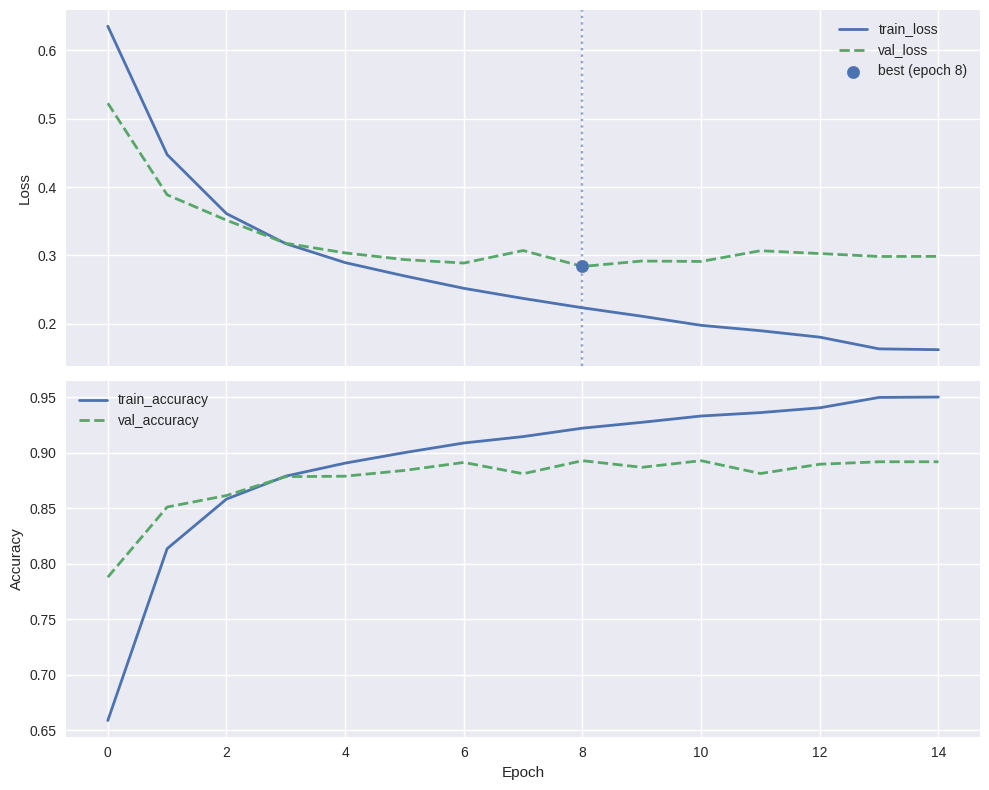

In [ ]:
plot_training_curve(dnn_csv_path_v2)

Test Loss:     0.2701
Test Accuracy: 0.8960

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.90      0.90      2500
    Positive       0.90      0.89      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



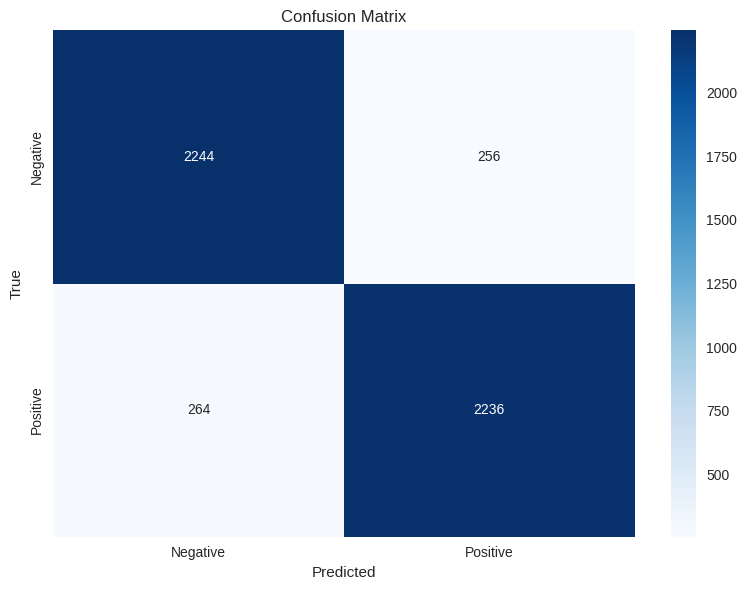

In [ ]:
evaluate_model(dnn_model_v2, test_ds, class_names=["Negative", "Positive"])

In [ ]:
dnn_model_v2.save("dnn_model_v2.keras")

##6.2. CNN Model (GloVe)

In [ ]:
cnn_model_v2 = build_model_v2(
    X_train_texts    = X_train,
    model_type       = "cnn",
    embedding_dim    = 100,
    embeddings_index = embeddings_index
)
cnn_model_v2.summary()


Embedding matrix: 19,266 hits, 734 misses out of 20,000 vocab tokens


Model: "multi_kernel_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 300)       │          0 │ text_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 100)  │  2,000,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 300, 100)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 300, 128)  │     38,528 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 300, 128)  │     51,328 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 300, 128)  │     64,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 300, 128)  │        512 │ conv_3[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_4                │ (None, 300, 128)  │        512 │ conv_4[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_5                │ (None, 300, 128)  │        512 │ conv_5[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 128)       │          0 │ bn_3[0][0]        │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4              │ (None, 128)       │          0 │ bn_4[0][0]        │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_5              │ (None, 128)       │          0 │ bn_5[0][0]        │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ pool_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ pool_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ pool_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 384)       │          0 │ dropout_7[0][0],  │
│                     │                   │            │ dropout_8[0][0],  │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     49,280 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]   

 Total params: 2,204,929 (8.41 MB)

 Trainable params: 2,204,161 (8.41 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
cnn_history_v2, cnn_model_v2, cnn_csv_path_v2 = train_model(
    cnn_model_v2, train_ds, val_ds,
    experiment_name="cnn_v2",
    epochs=40
)


Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5200 - loss: 1.0865 - val_accuracy: 0.6222 - val_loss: 0.7083 - learning_rate: 3.0000e-04
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.5523 - loss: 0.7033 - val_accuracy: 0.7518 - val_loss: 0.5802 - learning_rate: 3.0000e-04
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.6943 - loss: 0.5985 - val_accuracy: 0.8086 - val_loss: 0.4459 - learning_rate: 3.0000e-04
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7756 - loss: 0.4964 - val_accuracy: 0.8312 - val_loss: 0.3994 - learning_rate: 3.0000e-04
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8079 - loss: 0.4436 - val_accuracy: 0.8468 - val_loss: 0.3726 - learning_rate: 3.0000e-04
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.8290 - loss: 0.4071 - val_accuracy: 0.8540 - val_loss: 0.3506 - learning_rate: 3.0000e-04
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/ste

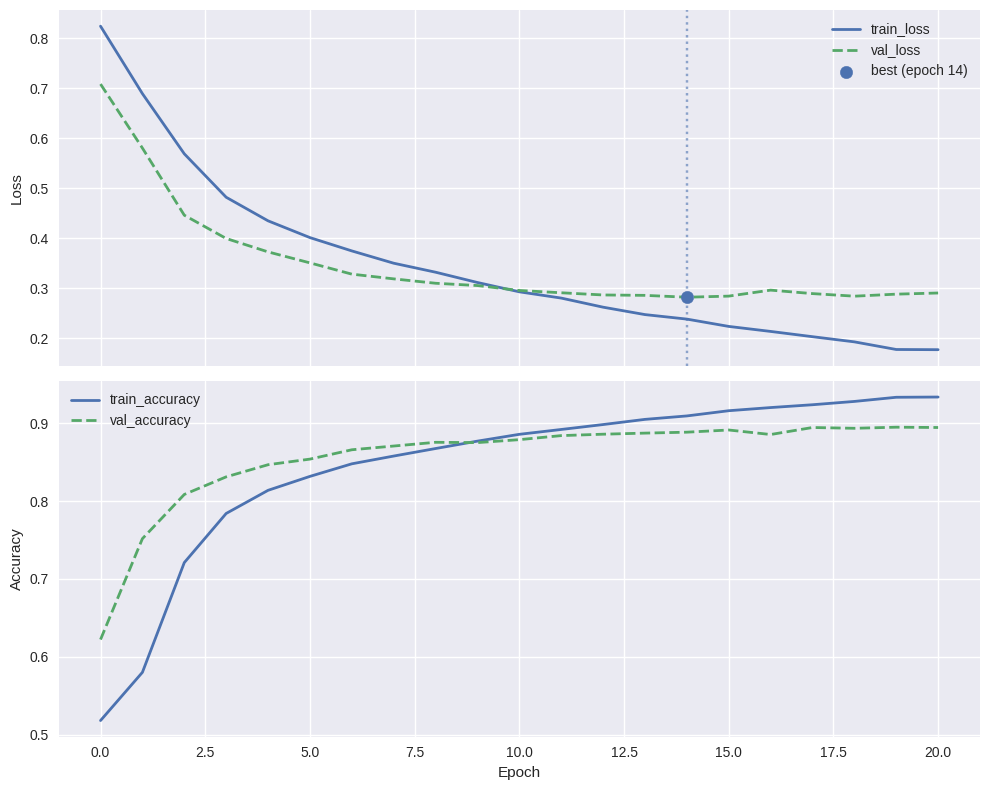

In [ ]:
plot_training_curve(cnn_csv_path_v2)

Test Loss:     0.2642
Test Accuracy: 0.8936

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      2500
    Positive       0.89      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



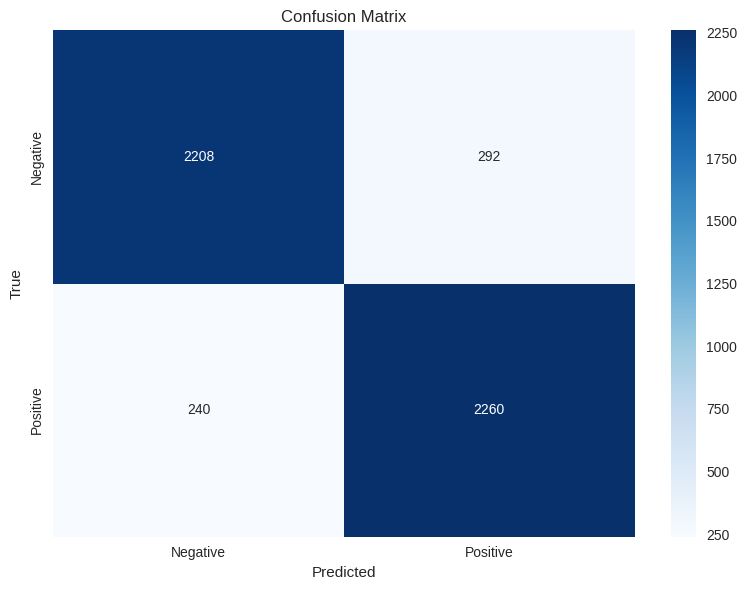

In [ ]:
evaluate_model(cnn_model_v2, test_ds, class_names=["Negative", "Positive"])

In [ ]:
cnn_model_v2.save("cnn_model_v2.keras")

##6.3. LSTM Model (GloVe)

In [ ]:
lstm_model_v2 = build_model_v2(
    X_train_texts    = X_train,
    model_type       = "lstm",
    embedding_dim    = 100,
    embeddings_index = embeddings_index
)
lstm_model_v2.summary()

Embedding matrix: 19,266 hits, 734 misses out of 20,000 vocab tokens


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_6            │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 300, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 300, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,133,889 (8.14 MB)

 Trainable params: 2,133,889 (8.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history_v2, lstm_model_v2, lstm_csv_path_v2 = train_model(
    lstm_model_v2,
    train_ds, val_ds,
    experiment_name="lstm_v2",
    epochs=40
)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5659 - loss: 0.6870 - val_accuracy: 0.7466 - val_loss: 0.5476 - learning_rate: 3.0000e-04
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7305 - loss: 0.5591 - val_accuracy: 0.8080 - val_loss: 0.4833 - learning_rate: 3.0000e-04
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7971 - loss: 0.4654 - val_accuracy: 0.8488 - val_loss: 0.3894 - learning_rate: 3.0000e-04
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8301 - loss: 0.3987 - val_accuracy: 0.8658 - val_loss: 0.3470 - learning_rate: 3.0000e-04
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8529 - loss: 0.3593 - val_accuracy: 0.8774 - val_loss: 0.2948 - learning_rate: 3.0000e-04
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8708 - loss: 0.3167 - val_accuracy: 0.8746 - val_loss: 0.3073 - learning_rate: 3.0000e-04
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/ste

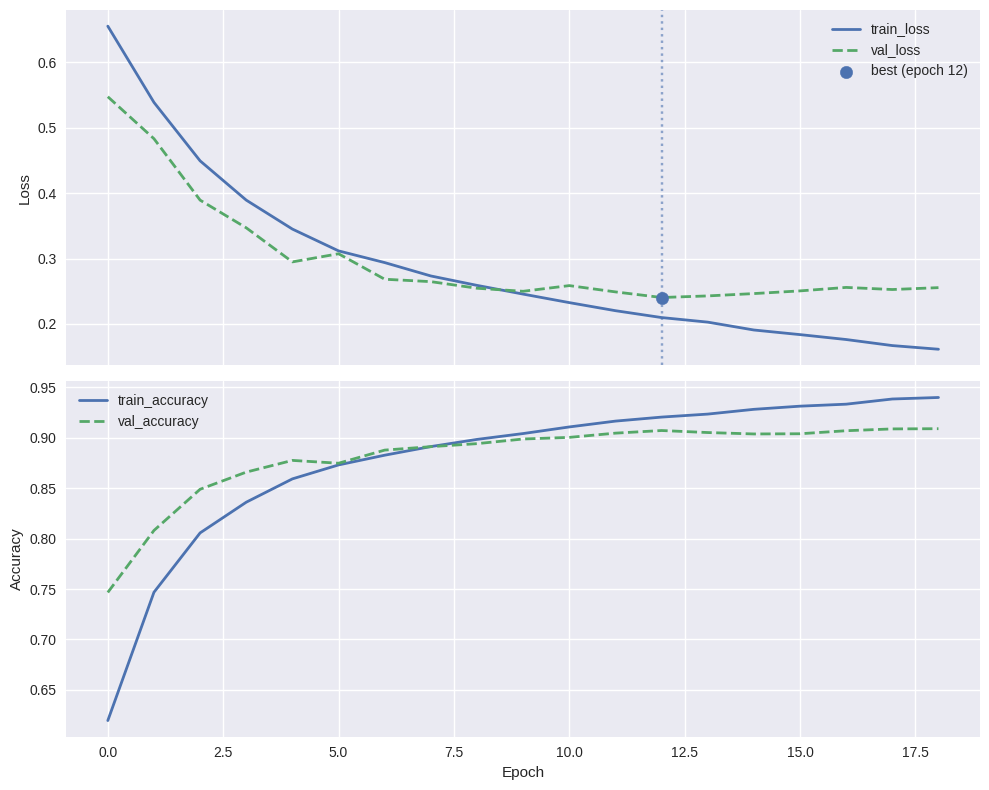

In [ ]:
plot_training_curve(lstm_csv_path_v2)

Test Loss:     0.2265
Test Accuracy: 0.9132

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.91      0.91      2500
    Positive       0.91      0.92      0.91      2500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



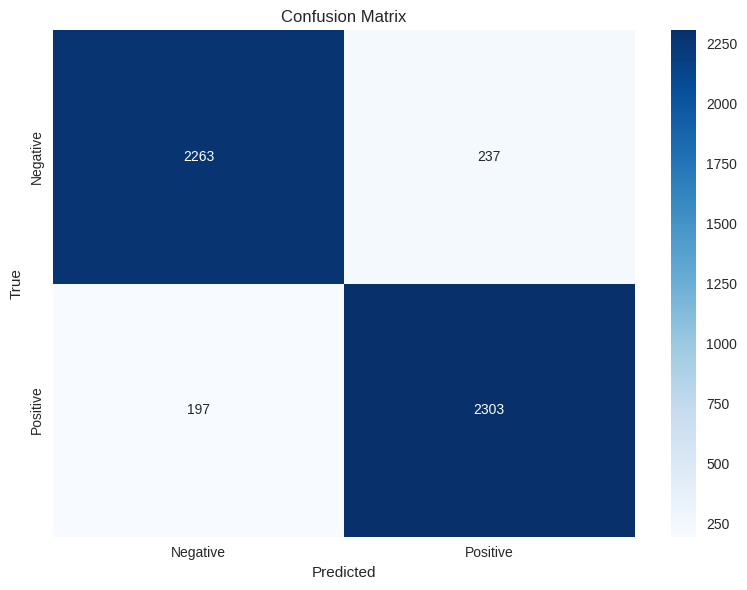

In [ ]:
evaluate_model(lstm_model_v2, test_ds, class_names=["Negative", "Positive"])

In [ ]:
lstm_model_v2.save("lstm_model_v2.keras")

##6.4. BiLSTM Model (GloVe)

In [ ]:
bilstm_model_v2 = build_model_v2(
    X_train_texts    = X_train,
    model_type       = "bilstm",
    embedding_dim    = 100,
    embeddings_index = embeddings_index
)
bilstm_model_v2.summary()

Embedding matrix: 19,266 hits, 734 misses out of 20,000 vocab tokens


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_9            │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_8 (Embedding)         │ (None, 300, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_7             │ (None, 300, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 300, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 300, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ __attention_pooling_2           │ (None, 128)            │           128 │
│ (_AttentionPooling)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,415,617 (9.21 MB)

 Trainable params: 2,415,617 (9.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
bilstm_history_v2, bilstm_model_v2, bilstm_csv_path_v2 = train_model(
    bilstm_model_v2, train_ds, val_ds,
    experiment_name="bilstm_v2",
    epochs=40
)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 72ms/step - accuracy: 0.5998 - loss: 0.6558 - val_accuracy: 0.8382 - val_loss: 0.3857 - learning_rate: 3.0000e-04
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8140 - loss: 0.4276 - val_accuracy: 0.8732 - val_loss: 0.3142 - learning_rate: 3.0000e-04
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.8485 - loss: 0.3571 - val_accuracy: 0.8698 - val_loss: 0.3091 - learning_rate: 3.0000e-04
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8698 - loss: 0.3178 - val_accuracy: 0.8836 - val_loss: 0.2782 - learning_rate: 3.0000e-04
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8830 - loss: 0.2898 - val_accuracy: 0.8804 - val_loss: 0.2894 - learning_rate: 3.0000e-04
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8918 - loss: 0.2725 - val_accuracy: 0.8896 - val_loss: 0.2648 - learning_rate: 3.0000e-04
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/ste

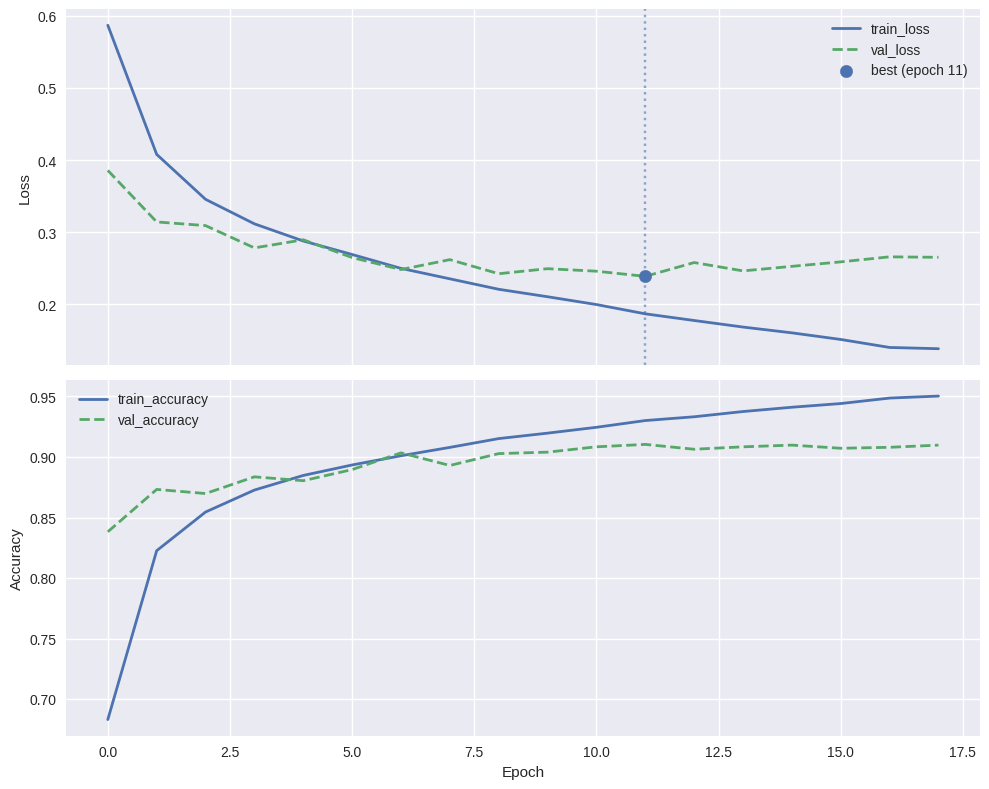

In [ ]:
plot_training_curve(bilstm_csv_path_v2)

Test Loss:     0.2298
Test Accuracy: 0.9112

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91      2500
    Positive       0.90      0.92      0.91      2500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



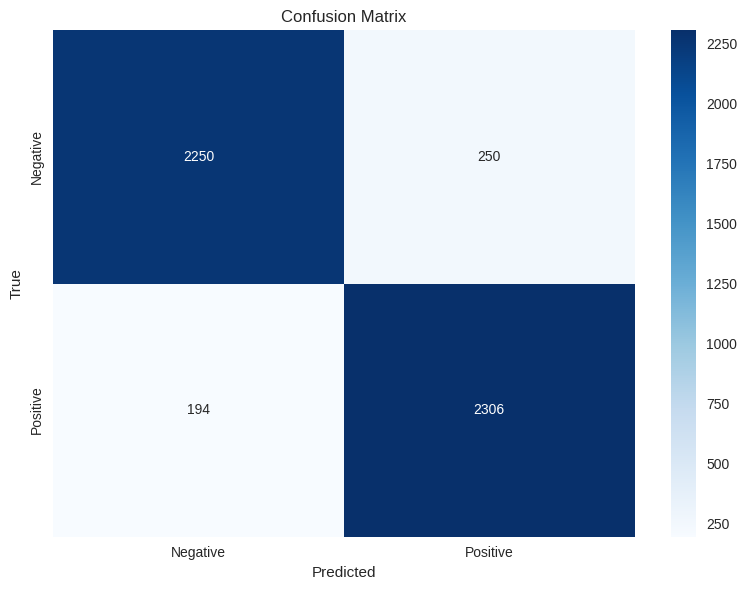

In [ ]:
evaluate_model(bilstm_model_v2, test_ds, class_names=["Negative", "Positive"])

In [ ]:
bilstm_model_v2.save("bilstm_model_v2.keras")